# Back Propagation Coded

In [310]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [311]:
def f(x):
    return 3 * x**2 + 4 * x + 5

In [312]:
f(3.0) 

44.0

In [313]:
xs = np.arange(-5, 5, 0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [314]:
ys = f(xs)
ys

array([60.    , 53.6875, 47.75  , 42.1875, 37.    , 32.1875, 27.75  ,
       23.6875, 20.    , 16.6875, 13.75  , 11.1875,  9.    ,  7.1875,
        5.75  ,  4.6875,  4.    ,  3.6875,  3.75  ,  4.1875,  5.    ,
        6.1875,  7.75  ,  9.6875, 12.    , 14.6875, 17.75  , 21.1875,
       25.    , 29.1875, 33.75  , 38.6875, 44.    , 49.6875, 55.75  ,
       62.1875, 69.    , 76.1875, 83.75  , 91.6875])

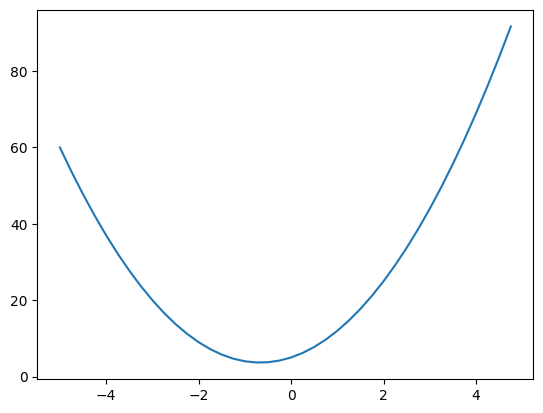

In [315]:
plt.plot(xs, ys)

Derivative
$$
\frac{d}{dx}[f(x)] = \lim_{h \to 0} \frac{f(x+h)-f(x)}{h}
$$

In [316]:
h = 0.00001
x = 3
df = (f(x+h) - f(x))/h
print(df)

22.000029999702516


In [317]:
def derivative(f,x,h=0.0001):
    return (f(x+h) - f(x))/h

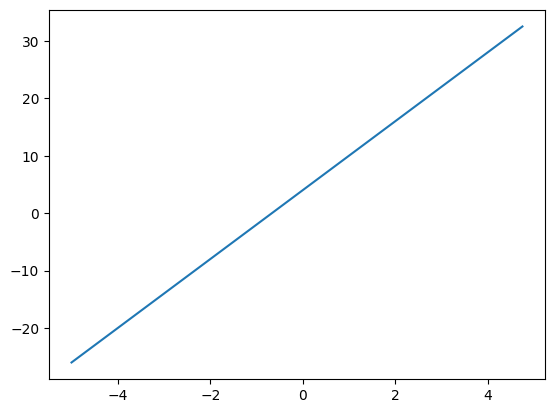

In [318]:
dfs = derivative(f, xs)
plt.plot(xs, dfs,0.0001)

Partial derivatives
$$
\frac{\partial f}{\partial x}, \quad \frac{\partial f}{\partial y}, \quad \frac{\partial f}{\partial z}
$$
$$
\frac{\partial f}{\partial x}
=
\lim_{h \to 0}
\frac{f(x+h, y, z)-f(x, y, z)}{h}
$$

In [319]:
a =2.0
b=-3.0
c = 10.0

d = lambda a,b,c: a*b +c
print(d(a,b,c))

4.0


In [320]:
print("derivative wrt a: ", (d(a+h, b, c)-d(a, b, c))/h)
print("derivative wrt b: ", (d(a, b+h, c)-d(a, b, c))/h)
print("derivative wrt c: ", (d(a, b, c+h)-d(a, b, c))/h)

derivative wrt a:  -3.000000000064062
derivative wrt b:  2.0000000000131024
derivative wrt c:  0.9999999999621422


In [321]:
class Value:
    def __init__(self,data, _children=(), _op='', label = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        # return Value(self.data + other.data, (self, other), '+' , label= self.label + '+' + other.label )
        out = Value(self.data + other.data, (self, other),
                    '+', label=self.label + '+' + other.label)
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        # return Value(self.data * other.data, (self, other), '*', label= self.label + '*' + other.label )
        out = Value(self.data * other.data, (self, other),
                    '*', label=self.label + '*' + other.label)
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out 
    
    def exp(self):
        t = math.exp(self.data)
        out = Value(t, (self,), 'exp')

        def _backward():
            self.grad += t * out.grad

        out._backward = _backward
        return out
    
    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1)/(math.exp(2*n) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t **2) * out.grad

        out._backward = _backward
        return out
    
    def backward(self): 
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        
        self.grad = 1
        for node in reversed(topo):
            node._backward()
    
    def __rmul__(self, other):
        return self*other
    
    def __radd__(self, other):
        return self + other
    
    def __truediv__(self, other):
        return self * other ** -1
    
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data ** other, (self, ), f'**{other}')

        def _backward():
            self.grad += ((other) * ((self.data)**(other-1)) * out.grad) if other else 0

        out._backward = _backward
        return out
    
    def __sub__(self, other):
        return self + (-other)

In [322]:
a =Value(2.0,label='a')
a

Value(data=2.0)

In [323]:
b = Value(3.0,label='b')
a+b
# a.__add__(b)

Value(data=5.0)

In [324]:
a*b

Value(data=6.0)

In [325]:
c = Value(10, label='c')
d1= a*b + c

In [326]:
d1._prev

{Value(data=10), Value(data=6.0)}

In [327]:
! pip install graphviz

In [328]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir':'LR'})

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        dot.node(name=uid, label = "{%s | data %.4f | grad: %.4f }" % (n.label, n.data, n.grad), shape = 'record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)

            dot.edge(uid+n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) +n2._op)

    return dot

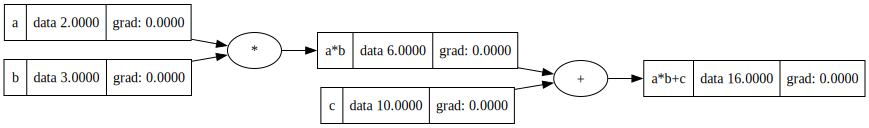

In [329]:
draw_dot(d1)

In [330]:
def lol():
    h=0.0001
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b
    e.label = 'e'
    d = e + c
    d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f
    L.label = 'L'
    L1 =L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b
    e.label = 'e'
    d = e + c
    d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f
    L.label = 'L'

In [331]:
d1.grad = 1.0

In [332]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1 * w1
x1w1.label = 'x1*w1'

x2w2 = x2 * w2
x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b
n.label = 'n'

o = n.tanh()
o.label = 'output'

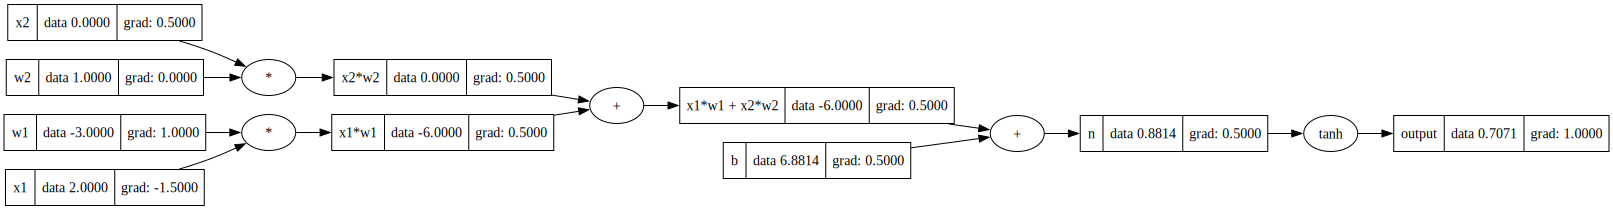

In [333]:
o.backward()
draw_dot(o)

In [334]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1 * w1
x1w1.label = 'x1*w1'

x2w2 = x2 * w2
x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b
n.label = 'n'

# o = n.tanh()
e = (2*n).exp()
o = (e-1)/(e+1)

o.label = 'output'

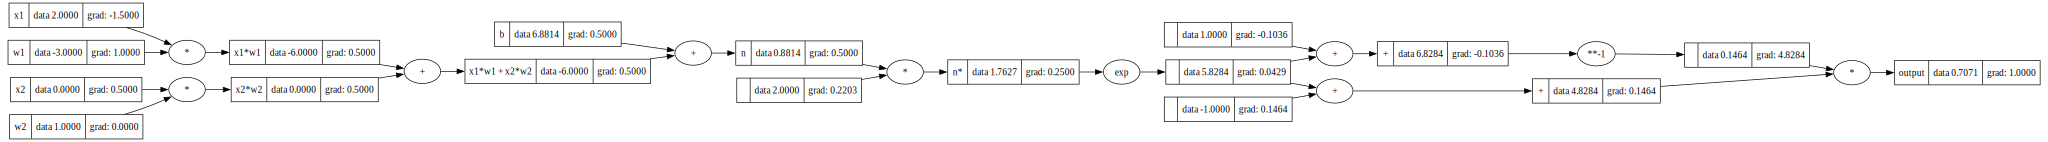

In [335]:
o.backward()
draw_dot(o)

In [336]:
n.grad = 1 - o.data **2

x1w1x2w2.grad = n.grad
b.grad = n.grad

x1w1.grad = x1w1x2w2.grad
x2w2.grad = x1w1x2w2.grad

x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

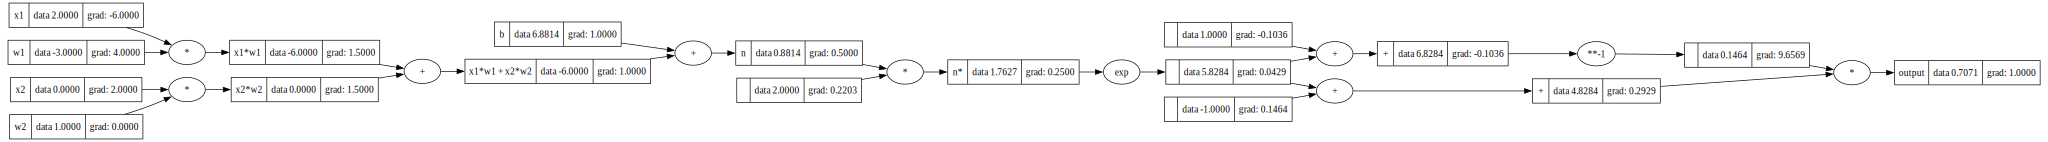

In [337]:
o.grad =1.0
o._backward()

n._backward()

x1w1x2w2._backward()

x1w1._backward()
x2w2._backward()

draw_dot(o)

[Value(data=-1), Value(data=6.881373587019543), Value(data=0.0), Value(data=1.0), Value(data=0.0), Value(data=-3.0), Value(data=2.0), Value(data=-6.0), Value(data=-6.0), Value(data=0.8813735870195432), Value(data=2), Value(data=1.7627471740390863), Value(data=5.828427124746192), Value(data=4.828427124746192), Value(data=1), Value(data=6.828427124746192), Value(data=0.1464466094067262), Value(data=0.7071067811865477)]


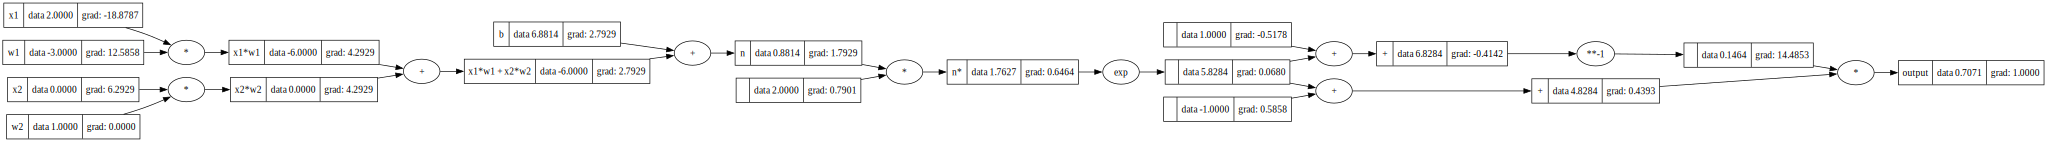

In [338]:
o.grad = 1.0

topo =[]

visited = set()

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
print(topo)

for node in reversed(topo):
    node._backward()
draw_dot(o)

In [339]:
a *2

Value(data=4.0)

In [340]:
import torch

x1 = torch.Tensor([2.0]).double()
x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()
x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()
w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()
w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()
b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [ ]:
class Neuron:
    
    